<a href="https://colab.research.google.com/github/Giorgosman13/RL_Assignment1/blob/main/Stohastic_Multi_Armed_Bandits_with_UCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programming Assignment 1 (Stochastic Bandits):Wireless Channel Allocation with Two Feedback Modes**

Author: *Giorgos Vassalos 2022030052*

# Initialization

First we need to import the necessary libraries for the program to work as well as create the seed:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

SEED = 52
np.random.seed(SEED)

Now we must create the SNR for each user using my personal seed and numpy functions such as random.unifrom which makes the uniform distibution we want for sij. We also initialize the values of K and epsilon with what the excercise sets:

In [ ]:
K=5
epsilon=0.6
#We create a (2,K) sized matrix that stores values from 0.8 to 2.0
s_baseline= np.random.uniform(0.8,2.0,(2,K))

After we create the s_baseline we list all the possible combinations of arms (actions) our algorithm can make without any duplicates. We do so using python's built in functions:

In [ ]:
arms=list(permutations(range(K),2))
print(arms)
print(len(arms))

[(0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3)]
20


We can now calculate the theoretical (without noise) expected rates for each played arm as well as the expected best action reward. Then we create a function where we calculate the theoretical rewards for a given arm:

In [ ]:
expected_rate = np.log(1+10*s_baseline)
expected_mij = np.array([expected_rate[0,i] + expected_rate[1,j] for i,j in arms])
expected_mbest = np.max(expected_mij)

def get_reward_theoretical(arm_ij):
  i,j=arms[arm_ij]

  s1_t = s_baseline[0,i]

  s2_t = s_baseline[1,j]

  r1 = np.log(1 + 10 * s1_t)
  r2 = np.log(1 + 10 * s2_t)

  return r1,r2

Since we have the theoretical values for our returns we should go into the simulation of the signal which **includes** noise where we must for each arm calculate the instantaneous value and calculate the rewards for a certain arm:

In [ ]:
def get_reward(arm_ij):
  i,j=arms[arm_ij]

  s1_t = np.random.uniform(s_baseline[0,i]-epsilon, s_baseline[0,i]+epsilon)

  s2_t = np.random.uniform(s_baseline[1,j]-epsilon, s_baseline[1,j]+epsilon)

  r1 = np.log(1 + 10 * s1_t)
  r2 = np.log(1 + 10 * s2_t)

  return (r1,r2)

# UCB implementation

#Case A

We now need to create our main run algorithm for each algorithm. That mode forces us to use only the aggregate value of reward and not use the individual values of it. Knowing this we can adapt the ucb algorithm to the scenario

*Task 0*
*   In this case the arm is the combination of the 2 channels
*   The learner after each round gathers the aggregate of our rewards
*  The quantity it wants to learn is the expected reward per arm

*Task 1*

In [ ]:
def run_ucb_A(T):
  regret = np.zeros(T)
  t_regret = 0

  Xin = np.zeros(len(arms))
  rin = np.zeros(len(arms))
  mu_hat = np.zeros(len(arms))

  arm_i = -1

  #Because of the no normalization rule we need to calculate the upper bound
  R_max=np.log(1+10*(2.0+epsilon))

  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    (r1,r2) = get_reward(arm_i)
    #What our algorithm has access to:
    reward = r1+r2
    rin[arm_i] += reward
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    t_regret += expected_mbest - reward
    regret[t] = t_regret

  return regret

In [ ]:
def run_ucb_A_theoretical(T):
  regret = np.zeros(T)
  t_regret = 0

  Xin = np.zeros(len(arms))
  rin = np.zeros(len(arms))
  mu_hat = np.zeros(len(arms))

  arm_i = -1

  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    (r1,r2) = get_reward_theoretical(arm_i)
    #What our algorithm has access to:
    reward = r1+r2
    rin[arm_i] += reward
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    t_regret += expected_mbest - reward
    regret[t] = t_regret

  return regret

# Case B

Case B gives us more info about the rewards since we can now gather info about the individual rewards for each user with each according channel. Knowing this we can adapt our ucb algorithm to the scenario:

*Task 0*
*   The arm in this case is the same as in case A so the arm is the combination of which signal goes to each user
*   The learner has access to the individual rates/rewards of each user with each signals.
*  My algorithm is trying to learn the expected reward per component.

*Task 2*



In [ ]:
def run_ucb_B(T):
  regret = np.zeros(T)
  t_regret = 0
  #2 users with 5 possible arms each so our tables are initialized as such
  Xin = np.zeros((2,K))
  rin = np.zeros((2,K))
  mu_hat = np.zeros((2,K))

  arm_i = -1

  #Because of the no normalization rule we need to calculate the upper bound
  R_max=np.log(1+10*(2.0+epsilon))

  for t in range(T):
    if t<K:
      i = t
      if t==4:
        j = 0
      else:
        j = t+1
      arm_i = arms.index((i,j))
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)

      reward_agg = [ucb_values[0, a[0]] + ucb_values[1, a[1]] for a in arms]
      arm_i = np.argmax(reward_agg)

    (r1,r2) = get_reward(arm_i)
    i,j = arms[arm_i]

    rin[0,i] += r1
    rin[1,j] += r2
    Xin[0,i] += 1
    Xin[1,j] += 1

    mu_hat[0,i] =rin[0,i] / Xin[0,i]
    mu_hat[1,j] =rin[1,j] / Xin[1,j]

    t_regret += expected_mbest - (r1+r2)
    regret[t] = t_regret

  return regret

In [ ]:
def run_ucb_B_theoretical(T):
  regret = np.zeros(T)
  t_regret = 0
  #2 users with 5 possible arms each so our tables are initialized as such
  Xin = np.zeros((2,K))
  rin = np.zeros((2,K))
  mu_hat = np.zeros((2,K))

  arm_i = -1

  #Because of the no normalization rule we need to calculate the upper bound
  R_max=np.log(1+10*(2.0+epsilon))

  for t in range(T):
    if t<K:
      i = t
      if t==4:
        j = 0
      else:
        j = t+1
      arm_i = arms.index((i,j))
    else:
      ucb_values = mu_hat + np.sqrt(2 * np.log(t+1) / Xin)

      reward_agg = [ucb_values[0, a[0]] + ucb_values[1, a[1]] for a in arms]
      arm_i = np.argmax(reward_agg)
    (r1,r2) = get_reward_theoretical(arm_i)
    i,j = arms[arm_i]

    rin[0,i] += r1
    rin[1,j] += r2
    Xin[0,i] += 1
    Xin[1,j] += 1

    mu_hat[0,i] =rin[0,i] / Xin[0,i]
    mu_hat[1,j] =rin[1,j] / Xin[1,j]

    t_regret += expected_mbest - (r1+r2)
    regret[t] = t_regret

  return regret

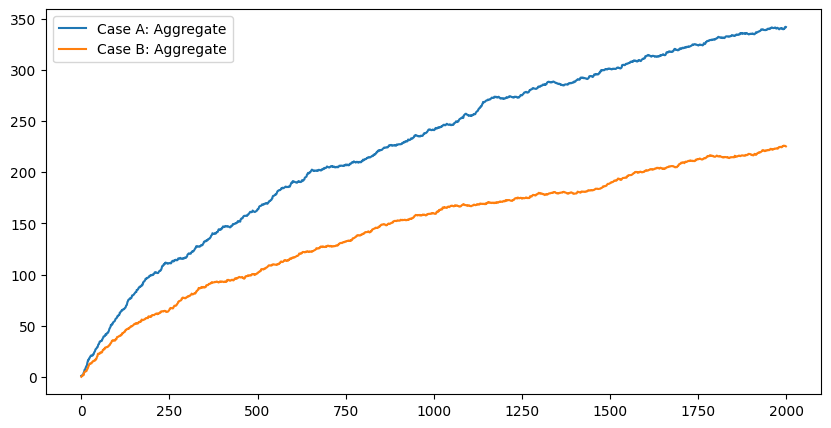

In [56]:
regret_a = run_ucb_A(2000)
regret_b = run_ucb_B(2000)
plt.figure(figsize=(10, 5))
plt.plot(regret_a, label='Case A: Aggregate')
plt.plot(regret_b, label='Case B: Aggregate')
plt.legend()

In [ ]:

def run_ucb(env, T, mode='A'):
    """
    mode='A': Aggregate feedback (learns 20 arms) [cite: 23]
    mode='B': Per-user feedback (learns 10 component rates) [cite: 28]
    """
    n_actions = env.n_actions
    regret = np.zeros(T)
    total_regret = 0

    # Range of sum-rate for tuning UCB [cite: 40, 45]
    # Max rate ~ log(1 + 10*2.6) * 2 ≈ 6.6. We use 7 as a safe bound for the range.
    R_MAX = 7.0

    if mode == 'A':
        counts = np.zeros(n_actions)
        values = np.zeros(n_actions)

        for t in range(T):
            if t < n_actions:
                action_idx = t
            else:
                # UCB formula [cite: 38]
                ucb_values = values + R_MAX * np.sqrt(2 * np.log(t+1) / counts)
                action_idx = np.argmax(ucb_values)

            r1, r2 = env.get_reward(action_idx)
            reward = r1 + r2  # Observed aggregate [cite: 25]

            # Update stats
            counts[action_idx] += 1
            values[action_idx] += (reward - values[action_idx]) / counts[action_idx]

            total_regret += env.best_action_value - env.mu_actions[action_idx]
            regret[t] = total_regret

    elif mode == 'B':
        # Learns individual components: 2 users x 5 channels = 10 "sub-arms"
        counts = np.zeros((2, env.K))
        values = np.zeros((2, env.K))

        for t in range(T):
            # Calculate UCB for each user-channel combination
            ucb_matrix = values + (R_MAX/2) * np.sqrt(2 * np.log(t+1) / (counts + 1e-9))

            # Select best joint action based on sum of component UCBs
            joint_ucbs = [ucb_matrix[0, j1] + ucb_matrix[1, j2] for j1, j2 in env.actions]
            action_idx = np.argmax(joint_ucbs)

            r1, r2 = env.get_reward(action_idx)
            j1, j2 = env.actions[action_idx]

            # Update individual components [cite: 29]
            counts[0, j1] += 1
            counts[1, j2] += 1
            values[0, j1] += (r1 - values[0, j1]) / counts[0, j1]
            values[1, j2] += (r2 - values[1, j2]) / counts[1, j2]

            total_regret += env.best_action_value - env.mu_actions[action_idx]
            regret[t] = total_regret

    return regret

# --- Simulation Execution [cite: 48] ---
env = WirelessEnvironment()
horizons = [2000, 20000]

for T in horizons:
    regret_A = run_ucb(env, T, mode='A')
    regret_B = run_ucb(env, T, mode='B')

plt.figure(figsize=(10, 5))
plt.plot(regret_A, label='Case A: Aggregate')
plt.plot(regret_B, label='Case B: Per-User')
plt.title(f'Cumulative Regret Comparison (T={T})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'WirelessEnvironment' is not defined